# Clustering Analysis

This notebook applies clustering techniques to identify recurring daily parking behaviour patterns across three parking sites.

The clustering analysis is conducted at the site-day level rather than on individual transactions. Each observation represents the daily behaviour of one parking site, based on demand volume, typical parking duration, payment activity, and entry-time distribution.

Three clustering methods are evaluated:

- K-Means as an interpretable baseline model
- Gaussian Mixture Model (GMM) as a probabilistic clustering model
- DBSCAN as a density-based method capable of identifying unusual observations

clustering objective is:

1. Site behavioural profiling: identifying how Site A, B and C differ
2. Daily parking behaviour profiling: identifying patterns such as high-demand weekday, low-demand weekend, unusual early-morning activity, regardless of which site produced them.

To avoid the model simply separating sites according to their different baseline activity levels, selected behavioural features are standardized relative to each site's usual behaviour before clustering.

## Import Libraries and Configure Paths

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

PROJECT_ROOT = Path(
    r"C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp"
)

INPUT_FILE = PROJECT_ROOT / "data" / "processed" / "parking_transactions_cleaned.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "clustering"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Input file:", INPUT_FILE)
print("Output directory:", OUTPUT_DIR)

Input file: C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp\data\processed\parking_transactions_cleaned.csv
Output directory: C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp\outputs\clustering


## Load and Validate the Cleaned Transaction Dataset

In [2]:
df = pd.read_csv(
    r"C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp\data\processed\parking_transactions_cleaned.csv",
    parse_dates=["transaction_dateIn", "transaction_dateOut", "entry_date"]
)

required_columns = [
    "id",
    "site",
    "entry_date",
    "entry_hour",
    "parking_duration_minutes",
    "amount",
    "is_paid",
    "is_weekend"
]

missing_required_columns = [
    column for column in required_columns if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        f"Missing required columns in cleaned dataset: {missing_required_columns}"
    )

print("Transaction-level dataset shape:", df.shape)
df.head()

Transaction-level dataset shape: (87440, 22)


,id,loc_id,reference_id,transaction_dateIn,transaction_dateOut,card_no,amount,card_type,batch_id,user_category,site,parking_duration_minutes,entry_date,entry_year,entry_month,entry_day,entry_hour,entry_day_name,entry_dayofweek_num,is_weekend,exit_hour,is_paid
0,43525,42,42202511756075005,2025-01-01 07:48:30,2025-01-01 07:55:26,2783752655,0.000,TNG,488,1,Site A,6.933,2025-01-01,2025,1,1,7,Wednesday,2,0,7,0
1,43530,42,422025111449019504,2025-01-01 14:41:08,2025-01-01 14:42:48,1882361935,0.000,TNG,488,1,Site A,1.667,2025-01-01,2025,1,1,14,Wednesday,2,0,14,0
2,43531,42,422025111514034412,2025-01-01 14:38:23,2025-01-01 15:10:48,2165653295,0.000,TNG,488,1,Site A,32.417,2025-01-01,2025,1,1,14,Wednesday,2,0,15,0
3,43532,42,422025111521010598,2025-01-01 10:16:10,2025-01-01 15:20:36,2783752655,10.000,TNG,488,1,Site A,304.433,2025-01-01,2025,1,1,10,Wednesday,2,0,15,1
4,43533,42,42202511177047676,2025-01-01 16:36:45,2025-01-01 17:03:01,1795549711,0.000,TNG,488,1,Site A,26.267,2025-01-01,2025,1,1,16,Wednesday,2,0,17,0


## Validity Check Before Clustering

In [3]:
# Convert analytical variables to numeric format where required
numeric_columns = [
    "entry_hour",
    "parking_duration_minutes",
    "amount",
    "is_paid",
    "is_weekend"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

initial_rows = len(df)

# Exclude records that cannot be used to derive daily behaviour
df = df.dropna(
    subset=[
        "site",
        "entry_date",
        "entry_hour",
        "parking_duration_minutes",
        "amount",
        "is_paid",
        "is_weekend"
    ]
).copy()

missing_removed = initial_rows - len(df)

# Remove logically invalid negative parking durations only
before_negative_filter = len(df)

df = df[df["parking_duration_minutes"] >= 0].copy()

negative_rows_removed = before_negative_filter - len(df)

print("Initial rows loaded:", initial_rows)
print("Rows removed due to missing analytical values:", missing_removed)
print("Rows removed due to negative duration:", negative_rows_removed)
print("Rows retained for clustering preparation:", len(df))

Initial rows loaded: 87440
Rows removed due to missing analytical values: 0
Rows removed due to negative duration: 0
Rows retained for clustering preparation: 87440


## Create Time-Period Behaviour Indicators

In [4]:
df["is_early_morning"] = df["entry_hour"].between(0, 5).astype(int)
df["is_morning"] = df["entry_hour"].between(6, 11).astype(int)
df["is_afternoon"] = df["entry_hour"].between(12, 17).astype(int)
df["is_evening"] = df["entry_hour"].between(18, 23).astype(int)

time_period_check = (
    df[
        [
            "is_early_morning",
            "is_morning",
            "is_afternoon",
            "is_evening"
        ]
    ]
    .sum(axis=1)
    .value_counts()
)

print("Each transaction should belong to exactly one time period:")
time_period_check

Each transaction should belong to exactly one time period:


1    87440
Name: count, dtype: int64

## Aggregate Transactions into Daily Site Behaviour

In [5]:
daily_df = (
    df.groupby(["site", "entry_date"], as_index=False)
      .agg(
          total_transactions=("id", "count"),
          median_duration=("parking_duration_minutes", "median"),
          avg_duration=("parking_duration_minutes", "mean"),
          avg_amount=("amount", "mean"),
          total_revenue=("amount", "sum"),
          paid_ratio=("is_paid", "mean"),
          early_morning_ratio=("is_early_morning", "mean"),
          morning_ratio=("is_morning", "mean"),
          afternoon_ratio=("is_afternoon", "mean"),
          evening_ratio=("is_evening", "mean"),
          is_weekend=("is_weekend", "first")
      )
)

print("Daily site-level dataset shape:", daily_df.shape)
daily_df.head()

Daily site-level dataset shape: (1013, 13)


,site,entry_date,total_transactions,median_duration,avg_duration,avg_amount,total_revenue,paid_ratio,early_morning_ratio,morning_ratio,afternoon_ratio,evening_ratio,is_weekend
0,Site A,2025-01-01,11,86.067,183.286,3.364,37.000,0.545,0.000,0.182,0.727,0.091,0
1,Site A,2025-01-02,32,104.142,196.616,4.750,152.000,0.594,0.000,0.406,0.469,0.125,0
2,Site A,2025-01-03,41,96.767,177.115,3.732,153.000,0.683,0.024,0.244,0.537,0.195,0
3,Site A,2025-01-04,13,175.800,239.712,3.538,46.000,0.769,0.077,0.154,0.615,0.154,1
4,Site A,2025-01-05,18,62.875,153.542,3.333,60.000,0.556,0.056,0.167,0.667,0.111,1


## Identify Extended-Duration Site-Days for Interpretation

In [6]:
q1 = daily_df["median_duration"].quantile(0.25)
q3 = daily_df["median_duration"].quantile(0.75)
iqr = q3 - q1
duration_upper_fence = q3 + (1.5 * iqr)

daily_df["extended_duration_flag"] = (
    daily_df["median_duration"] > duration_upper_fence
).astype(int)

extended_duration_days = (
    daily_df[daily_df["extended_duration_flag"] == 1]
    .sort_values("median_duration", ascending=False)
)

print("Q1:", round(q1, 3))
print("Q3:", round(q3, 3))
print("IQR:", round(iqr, 3))
print("Upper fence:", round(duration_upper_fence, 3))
print("Number of flagged extended-duration site-days:", len(extended_duration_days))

extended_duration_days.head(20)

Q1: 131.508
Q3: 750.333
IQR: 618.825
Upper fence: 1678.571
Number of flagged extended-duration site-days: 20


,site,entry_date,total_transactions,median_duration,avg_duration,avg_amount,total_revenue,paid_ratio,early_morning_ratio,morning_ratio,afternoon_ratio,evening_ratio,is_weekend,extended_duration_flag
519,Site B,2025-07-12,2,"15,045.083","15,045.083",0.000,0.000,0.000,0.000,0.000,1.000,0.000,1,1
551,Site B,2025-08-16,1,"12,543.367","12,543.367",0.000,0.000,0.000,0.000,0.000,1.000,0.000,1,1
612,Site B,2025-11-01,1,"8,017.567","8,017.567",0.000,0.000,0.000,0.000,0.000,1.000,0.000,1,1
606,Site B,2025-10-25,1,"7,101.783","7,101.783",0.000,0.000,0.000,0.000,0.000,1.000,0.000,1,1
384,Site B,2025-01-25,2,"6,460.592","6,460.592",0.000,0.000,0.000,0.000,0.500,0.500,0.000,1,1
601,Site B,2025-10-18,1,"5,937.000","5,937.000",0.000,0.000,0.000,0.000,1.000,0.000,0.000,1,1
767,Site C,2025-04-14,4,"5,043.800","4,687.017",45.000,180.000,1.000,1.000,0.000,0.000,0.000,0,1
423,Site B,2025-03-16,1,"4,814.217","4,814.217",0.000,0.000,0.000,1.000,0.000,0.000,0.000,1,1
636,Site B,2025-11-29,3,"4,776.450","5,273.361",0.000,0.000,0.000,0.000,0.333,0.333,0.333,1,1
589,Site B,2025-10-04,4,"3,397.125","2,619.500",8.750,35.000,0.500,0.000,1.000,0.000,0.000,1,1


In [7]:
extended_duration_days.to_csv(
    TABLE_DIR / "flagged_extended_duration_days.csv",
    index=False
)

print("Extended-duration days by site:")
display(extended_duration_days["site"].value_counts())

print("Extended-duration days by weekend status:")
display(extended_duration_days["is_weekend"].value_counts())

Extended-duration days by site:


site
Site B    18
Site C     2
Name: count, dtype: int64

Extended-duration days by weekend status:


is_weekend
1    19
0     1
Name: count, dtype: int64

## Define Modelling Features

Features used in clustering

| Feature                  | Why it is used                                                                      |
| ------------------------ | ----------------------------------------------------------------------------------- |
| `log_total_transactions` | Represents demand intensity while reducing the effect of very busy days.            |
| `log_median_duration`    | Represents typical parking duration while limiting the effect of extreme durations. |
| `paid_ratio`             | Represents the proportion of transactions involving payment.                        |
| `early_morning_ratio`    | Represents unusual or early operational activity.                                   |
| `morning_ratio`          | Represents normal morning demand activity.                                          |
| `afternoon_ratio`        | Represents afternoon demand activity.                                               |

Features retained only for interpretation

| Feature         | Why it is not directly used in clustering                                                      |
| --------------- | ---------------------------------------------------------------------------------------------- |
| `avg_amount`    | Payment value may be driven by site pricing rather than usage behaviour.                       |
| `total_revenue` | Useful for recommendations but could make clusters reflect revenue scale instead of behaviour. |
| `is_weekend`    | Used to explain clusters after modelling rather than forcing weekday/weekend separation.       |
| `evening_ratio` | Excluded because time-period ratios together sum to one and would duplicate information.       |
| `site`          | Used to interpret cluster composition; not included as a model feature.                        |



In [8]:
daily_df["log_total_transactions"] = np.log1p(
    daily_df["total_transactions"]
)

daily_df["log_median_duration"] = np.log1p(
    daily_df["median_duration"]
)

model_features = [
    "log_total_transactions",
    "log_median_duration",
    "paid_ratio",
    "early_morning_ratio",
    "morning_ratio",
    "afternoon_ratio"
]

interpretation_features = [
    "total_transactions",
    "median_duration",
    "avg_duration",
    "avg_amount",
    "total_revenue",
    "paid_ratio",
    "early_morning_ratio",
    "morning_ratio",
    "afternoon_ratio",
    "evening_ratio",
    "is_weekend",
    "extended_duration_flag"
]

daily_df[model_features].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
log_total_transactions,"1,013.000",4.072,1.082,0.693,3.584,4.543,4.812,5.416
log_median_duration,"1,013.000",5.766,1.002,1.313,4.887,6.125,6.622,9.619
paid_ratio,"1,013.000",0.638,0.276,0.000,0.333,0.738,0.864,1.000
early_morning_ratio,"1,013.000",0.145,0.211,0.000,0.000,0.000,0.266,1.000
morning_ratio,"1,013.000",0.484,0.246,0.000,0.250,0.490,0.715,1.000
afternoon_ratio,"1,013.000",0.252,0.146,0.000,0.161,0.218,0.309,1.000


## Examine Correlation Among Selected Features

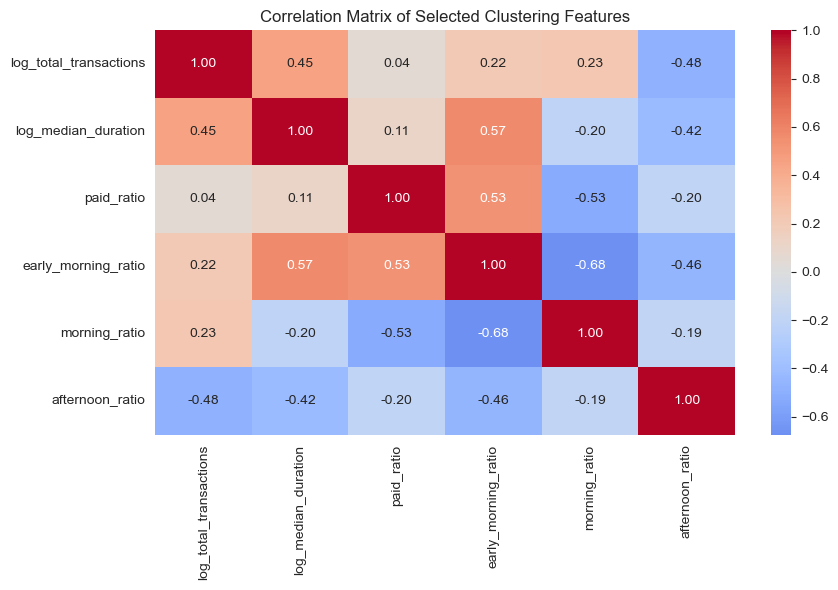

In [9]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    daily_df[model_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Selected Clustering Features")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "clustering_feature_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Standardize Behaviour Relative to Each Site

In [10]:
relative_features = []

for feature in model_features:
    site_mean = daily_df.groupby("site")[feature].transform("mean")
    site_std = daily_df.groupby("site")[feature].transform("std")

    relative_feature = f"{feature}_relative"

    daily_df[relative_feature] = (
        (daily_df[feature] - site_mean) / site_std.replace(0, np.nan)
    ).fillna(0)

    relative_features.append(relative_feature)

X = daily_df[relative_features].copy()

print("Features used for clustering:")
print(relative_features)

print("\nMissing values in clustering matrix:")
print(X.isnull().sum())

X.describe().transpose()

Features used for clustering:
['log_total_transactions_relative', 'log_median_duration_relative', 'paid_ratio_relative', 'early_morning_ratio_relative', 'morning_ratio_relative', 'afternoon_ratio_relative']

Missing values in clustering matrix:
log_total_transactions_relative    0
log_median_duration_relative       0
paid_ratio_relative                0
early_morning_ratio_relative       0
morning_ratio_relative             0
afternoon_ratio_relative           0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
log_total_transactions_relative,"1,013.000",-0.000,0.999,-7.822,-0.048,0.357,0.535,1.817
log_median_duration_relative,"1,013.000",-0.000,0.999,-11.473,-0.150,0.144,0.279,4.222
paid_ratio_relative,"1,013.000",-0.000,0.999,-10.019,-0.369,0.065,0.551,5.082
early_morning_ratio_relative,"1,013.000",0.000,0.999,-2.312,-0.532,-0.120,0.342,11.278
morning_ratio_relative,"1,013.000",-0.000,0.999,-3.683,-0.519,0.122,0.565,5.794
afternoon_ratio_relative,"1,013.000",0.000,0.999,-2.254,-0.490,-0.161,0.313,8.130


## K-Means Evaluation and Model Fitting

K-Means is retained as the baseline because it produces clear, mutually exclusive behavioural groups that are straightforward to interpret.

In [11]:
MIN_CLUSTER_PERCENTAGE = 5
kmeans_results = []
kmeans_models = {}

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = model.fit_predict(X)
    cluster_counts = pd.Series(labels).value_counts()
    minimum_cluster_percentage = (
        cluster_counts.min() / len(labels)
    ) * 100

    kmeans_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(X, labels),
        "davies_bouldin_index": davies_bouldin_score(X, labels),
        "smallest_cluster_size": cluster_counts.min(),
        "smallest_cluster_percentage": minimum_cluster_percentage
    })

    kmeans_models[k] = model

kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df

,k,inertia,silhouette_score,davies_bouldin_index,smallest_cluster_size,smallest_cluster_percentage
0,2,"4,656.199",0.509,1.414,150,14.808
1,3,"4,134.648",0.257,1.439,115,11.352
2,4,"3,694.194",0.213,1.547,37,3.653
3,5,"3,320.236",0.211,1.192,2,0.197
4,6,"2,972.046",0.213,1.236,2,0.197


In [12]:
eligible_kmeans = kmeans_results_df[
    kmeans_results_df["smallest_cluster_percentage"] >= MIN_CLUSTER_PERCENTAGE
].copy()

selected_kmeans_row = (
    eligible_kmeans
    .sort_values(
        by=["silhouette_score", "davies_bouldin_index"],
        ascending=[False, True]
    )
    .iloc[0]
)

selected_k = int(selected_kmeans_row["k"])

print("Automatically selected K-Means cluster count:", selected_k)
print(selected_kmeans_row)

Automatically selected K-Means cluster count: 2
k                                 2.000
inertia                       4,656.199
silhouette_score                  0.509
davies_bouldin_index              1.414
smallest_cluster_size           150.000
smallest_cluster_percentage      14.808
Name: 0, dtype: float64


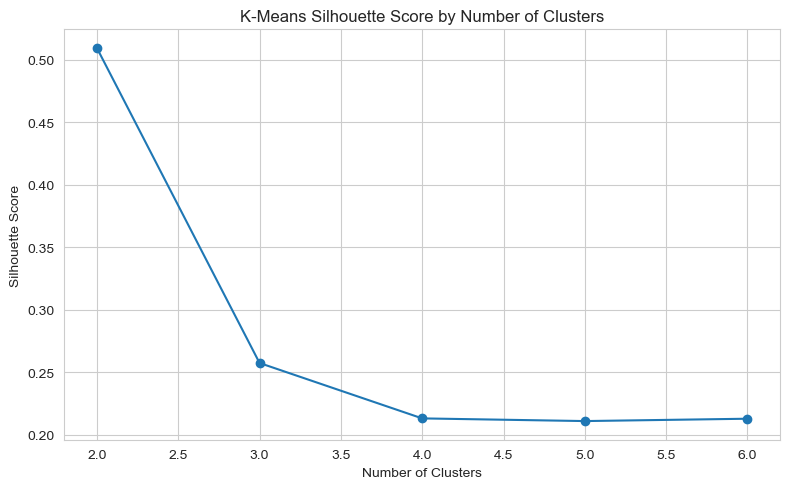

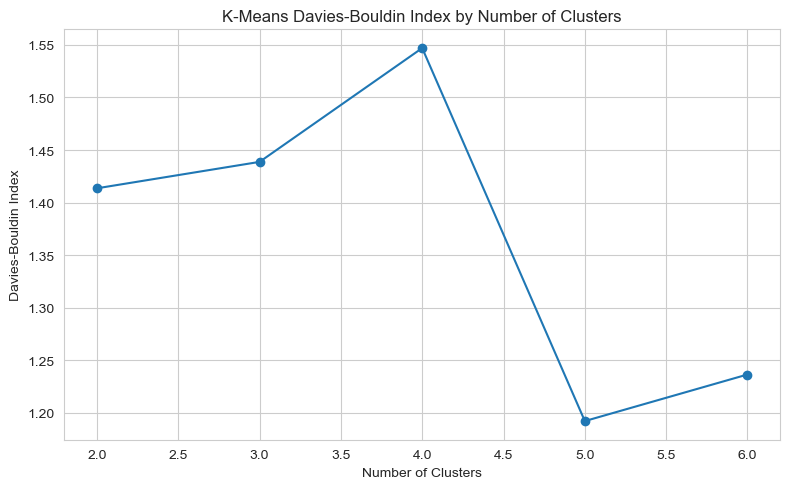

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results_df["k"],
    kmeans_results_df["silhouette_score"],
    marker="o"
)
plt.title("K-Means Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "kmeans_silhouette_by_k.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    kmeans_results_df["k"],
    kmeans_results_df["davies_bouldin_index"],
    marker="o"
)
plt.title("K-Means Davies-Bouldin Index by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "kmeans_davies_bouldin_by_k.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [14]:
kmeans_final = kmeans_models[selected_k]
daily_df["kmeans_cluster"] = kmeans_final.labels_

print(
    "K-Means Silhouette Score:",
    round(
        silhouette_score(X, daily_df["kmeans_cluster"]),
        4
    )
)

print(
    "K-Means Davies-Bouldin Index:",
    round(
        davies_bouldin_score(X, daily_df["kmeans_cluster"]),
        4
    )
)

print("\nK-Means Cluster Sizes:")
display(
    daily_df["kmeans_cluster"]
    .value_counts()
    .sort_index()
)

K-Means Silhouette Score: 0.5092
K-Means Davies-Bouldin Index: 1.4136

K-Means Cluster Sizes:


kmeans_cluster
0    150
1    863
Name: count, dtype: int64

## Gaussian Mixture Model Evaluation and Fitting

In [15]:
gmm_results = []
gmm_models = {}

for components in range(2, 7):
    model = GaussianMixture(
        n_components=components,
        random_state=42,
        n_init=10,
        covariance_type="full"
    )

    labels = model.fit_predict(X)
    cluster_counts = pd.Series(labels).value_counts()
    minimum_cluster_percentage = (
        cluster_counts.min() / len(labels)
    ) * 100

    gmm_results.append({
        "components": components,
        "bic": model.bic(X),
        "aic": model.aic(X),
        "silhouette_score": silhouette_score(X, labels),
        "davies_bouldin_index": davies_bouldin_score(X, labels),
        "smallest_cluster_size": cluster_counts.min(),
        "smallest_cluster_percentage": minimum_cluster_percentage
    })

    gmm_models[components] = model

gmm_results_df = pd.DataFrame(gmm_results)
gmm_results_df

,components,bic,aic,silhouette_score,davies_bouldin_index,smallest_cluster_size,smallest_cluster_percentage
0,2,"11,501.209","11,230.572",0.406,2.059,251,24.778
1,3,"10,337.376","9,928.960",0.074,2.048,214,21.125
2,4,"10,102.766","9,556.571",0.080,2.979,53,5.232
3,5,"7,168.700","6,484.727",0.041,2.904,52,5.133
4,6,"4,978.976","4,157.224",0.011,3.386,40,3.949


In [16]:
eligible_gmm = gmm_results_df[
    gmm_results_df["smallest_cluster_percentage"] >= MIN_CLUSTER_PERCENTAGE
].copy()

selected_gmm_row = (
    eligible_gmm
    .sort_values(
        by=["silhouette_score", "davies_bouldin_index"],
        ascending=[False, True]
    )
    .iloc[0]
)

selected_components = int(selected_gmm_row["components"])

print("Automatically selected GMM component count:", selected_components)
print(selected_gmm_row)

Automatically selected GMM component count: 2
components                         2.000
bic                           11,501.209
aic                           11,230.572
silhouette_score                   0.406
davies_bouldin_index               2.059
smallest_cluster_size            251.000
smallest_cluster_percentage       24.778
Name: 0, dtype: float64


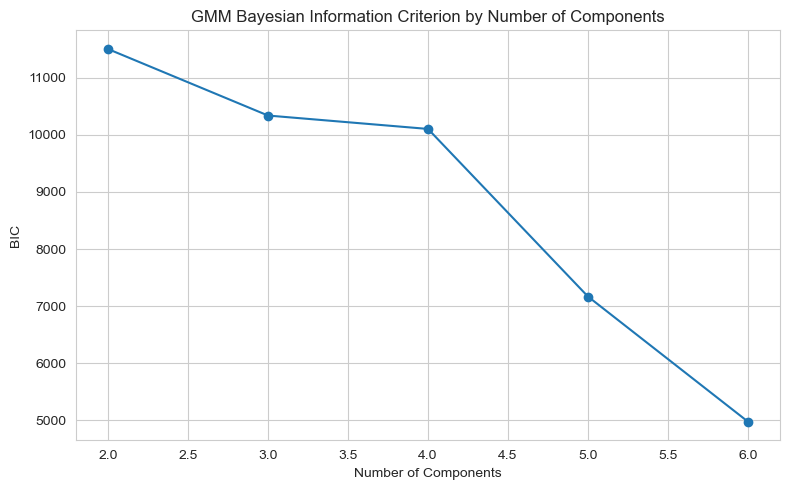

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    gmm_results_df["components"],
    gmm_results_df["bic"],
    marker="o"
)
plt.title("GMM Bayesian Information Criterion by Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "gmm_bic_by_components.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [18]:
gmm_final = gmm_models[selected_components]
daily_df["gmm_cluster"] = gmm_final.predict(X)

print(
    "GMM Silhouette Score:",
    round(
        silhouette_score(X, daily_df["gmm_cluster"]),
        4
    )
)

print(
    "GMM Davies-Bouldin Index:",
    round(
        davies_bouldin_score(X, daily_df["gmm_cluster"]),
        4
    )
)

print("\nGMM Cluster Sizes:")
display(
    daily_df["gmm_cluster"]
    .value_counts()
    .sort_index()
)

GMM Silhouette Score: 0.4061
GMM Davies-Bouldin Index: 2.0585

GMM Cluster Sizes:


gmm_cluster
0    762
1    251
Name: count, dtype: int64

## DBSCAN Evaluation and Fitting

In [19]:
dbscan_results = []
dbscan_models = {}

eps_values = np.arange(0.3, 1.6, 0.1)
min_samples_values = [5, 8, 10, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(
            eps=float(round(eps, 1)),
            min_samples=min_samples
        )

        labels = model.fit_predict(X)

        cluster_labels = [
            label for label in np.unique(labels)
            if label != -1
        ]

        number_of_clusters = len(cluster_labels)
        noise_points = int((labels == -1).sum())
        noise_percentage = (noise_points / len(labels)) * 100

        valid_mask = labels != -1

        if number_of_clusters >= 2:
            valid_cluster_counts = (
                pd.Series(labels[valid_mask])
                .value_counts()
            )

            smallest_cluster_percentage = (
                valid_cluster_counts.min() / len(labels)
            ) * 100

            silhouette = silhouette_score(
                X.loc[valid_mask],
                labels[valid_mask]
            )

            dbi = davies_bouldin_score(
                X.loc[valid_mask],
                labels[valid_mask]
            )
        else:
            smallest_cluster_percentage = np.nan
            silhouette = np.nan
            dbi = np.nan

        dbscan_results.append({
            "eps": round(float(eps), 1),
            "min_samples": min_samples,
            "clusters": number_of_clusters,
            "noise_points": noise_points,
            "noise_percentage": noise_percentage,
            "smallest_cluster_percentage": smallest_cluster_percentage,
            "silhouette_score_excluding_noise": silhouette,
            "davies_bouldin_excluding_noise": dbi
        })

        dbscan_models[(round(float(eps), 1), min_samples)] = model

dbscan_results_df = pd.DataFrame(dbscan_results)

dbscan_results_df.sort_values(
    by=[
        "silhouette_score_excluding_noise",
        "noise_percentage"
    ],
    ascending=[False, True]
).head(15)

,eps,min_samples,clusters,noise_points,noise_percentage,smallest_cluster_percentage,silhouette_score_excluding_noise,davies_bouldin_excluding_noise
36,1.200,5,2,110,10.859,0.592,0.735,0.274
44,1.400,5,2,82,8.095,0.592,0.720,0.285
48,1.500,5,2,75,7.404,0.592,0.715,0.288
40,1.300,5,3,93,9.181,0.494,0.513,0.455
1,0.300,8,2,785,77.493,4.245,0.492,0.749
2,0.300,10,2,789,77.887,3.949,0.488,0.738
3,0.300,15,2,803,79.269,3.060,0.482,0.706
41,1.300,8,3,118,11.649,0.691,0.476,0.725
46,1.400,10,2,108,10.661,0.790,0.476,0.609
19,0.700,15,2,355,35.044,2.764,0.464,0.646


In [20]:
MAX_NOISE_PERCENTAGE = 20
MIN_DBSCAN_CLUSTER_PERCENTAGE = 2.5

eligible_dbscan = dbscan_results_df[
    (dbscan_results_df["clusters"] >= 2) &
    (dbscan_results_df["clusters"] <= 6) &
    (dbscan_results_df["noise_percentage"] <= MAX_NOISE_PERCENTAGE) &
    (
        dbscan_results_df["smallest_cluster_percentage"]
        >= MIN_DBSCAN_CLUSTER_PERCENTAGE
    )
].copy()

if eligible_dbscan.empty:
    print(
        "No DBSCAN model met the preferred constraints. "
        "The least noisy evaluable solution will be retained for review."
    )

    eligible_dbscan = dbscan_results_df[
        dbscan_results_df["clusters"] >= 2
    ].copy()

selected_dbscan_row = (
    eligible_dbscan
    .sort_values(
        by=[
            "silhouette_score_excluding_noise",
            "noise_percentage"
        ],
        ascending=[False, True]
    )
    .iloc[0]
)

selected_eps = float(selected_dbscan_row["eps"])
selected_min_samples = int(selected_dbscan_row["min_samples"])

print("Selected DBSCAN eps:", selected_eps)
print("Selected DBSCAN min_samples:", selected_min_samples)
print(selected_dbscan_row)

No DBSCAN model met the preferred constraints. The least noisy evaluable solution will be retained for review.
Selected DBSCAN eps: 1.2
Selected DBSCAN min_samples: 5
eps                                  1.200
min_samples                          5.000
clusters                             2.000
noise_points                       110.000
noise_percentage                    10.859
smallest_cluster_percentage          0.592
silhouette_score_excluding_noise     0.735
davies_bouldin_excluding_noise       0.274
Name: 36, dtype: float64


In [21]:
dbscan_final = dbscan_models[
    (selected_eps, selected_min_samples)
]

daily_df["dbscan_cluster"] = dbscan_final.fit_predict(X)
daily_df["dbscan_noise_flag"] = (
    daily_df["dbscan_cluster"] == -1
).astype(int)

print("\nDBSCAN Cluster Sizes:")
display(
    daily_df["dbscan_cluster"]
    .value_counts()
    .sort_index()
)

print(
    "DBSCAN noise observations:",
    daily_df["dbscan_noise_flag"].sum()
)


DBSCAN Cluster Sizes:


dbscan_cluster
-1    110
 0    897
 1      6
Name: count, dtype: int64

DBSCAN noise observations: 110


## Compare Clustering Models

In [22]:
dbscan_valid_mask = daily_df["dbscan_cluster"] != -1

model_comparison = pd.DataFrame([
    {
        "model": "K-Means",
        "selected_clusters": selected_k,
        "silhouette_score": silhouette_score(
            X,
            daily_df["kmeans_cluster"]
        ),
        "davies_bouldin_index": davies_bouldin_score(
            X,
            daily_df["kmeans_cluster"]
        ),
        "noise_percentage": 0.0,
        "metric_basis": "All observations"
    },
    {
        "model": "GMM",
        "selected_clusters": selected_components,
        "silhouette_score": silhouette_score(
            X,
            daily_df["gmm_cluster"]
        ),
        "davies_bouldin_index": davies_bouldin_score(
            X,
            daily_df["gmm_cluster"]
        ),
        "noise_percentage": 0.0,
        "metric_basis": "All observations"
    },
    {
        "model": "DBSCAN",
        "selected_clusters": len(
            set(daily_df["dbscan_cluster"]) - {-1}
        ),
        "silhouette_score": silhouette_score(
            X.loc[dbscan_valid_mask],
            daily_df.loc[dbscan_valid_mask, "dbscan_cluster"]
        ),
        "davies_bouldin_index": davies_bouldin_score(
            X.loc[dbscan_valid_mask],
            daily_df.loc[dbscan_valid_mask, "dbscan_cluster"]
        ),
        "noise_percentage": (
            daily_df["dbscan_noise_flag"].mean() * 100
        ),
        "metric_basis": "Noise observations excluded"
    }
]).round(4)

model_comparison

,model,selected_clusters,silhouette_score,davies_bouldin_index,noise_percentage,metric_basis
0,K-Means,2,0.509,1.414,0.000,All observations
1,GMM,2,0.406,2.058,0.000,All observations
2,DBSCAN,2,0.735,0.274,10.859,Noise observations excluded


In [23]:
model_comparison.to_csv(
    TABLE_DIR / "clustering_model_comparison.csv",
    index=False
)

kmeans_results_df.to_csv(
    TABLE_DIR / "kmeans_candidate_results.csv",
    index=False
)

gmm_results_df.to_csv(
    TABLE_DIR / "gmm_candidate_results.csv",
    index=False
)

dbscan_results_df.to_csv(
    TABLE_DIR / "dbscan_candidate_results.csv",
    index=False
)

How to interpret the comparison

- Higher Silhouette Score is better.
- Lower Davies-Bouldin Index is better.
- DBSCAN metrics must be interpreted together with its noise percentage.
- Do not automatically choose DBSCAN only because its scores are stronger if it excludes a large portion of the observations as noise.

## PCA Visualization of Model Outputs

In [24]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X)

daily_df["PCA1"] = pca_components[:, 0]
daily_df["PCA2"] = pca_components[:, 1]

explained_variance = pca.explained_variance_ratio_.sum()

print(
    "Variance represented by two PCA dimensions:",
    round(explained_variance * 100, 2),
    "%"
)

Variance represented by two PCA dimensions: 58.76 %


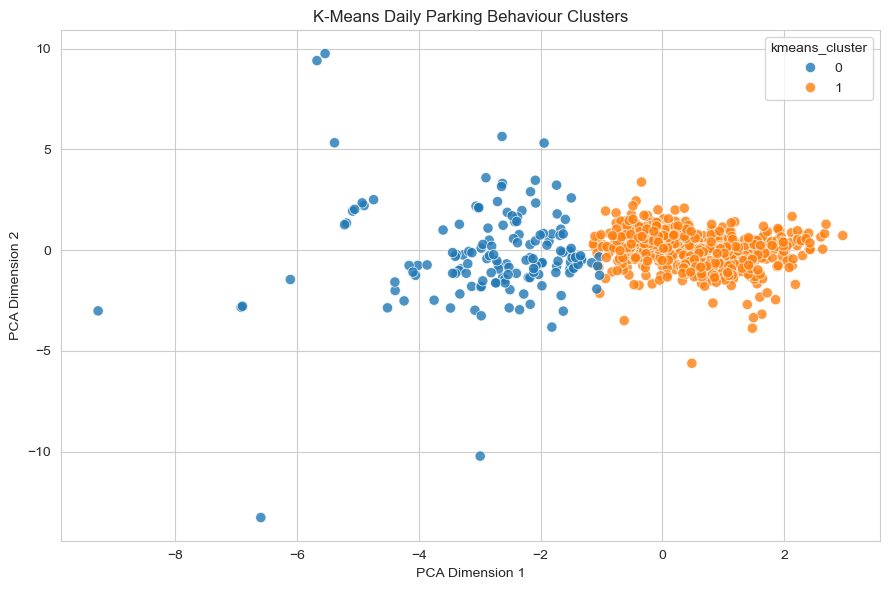

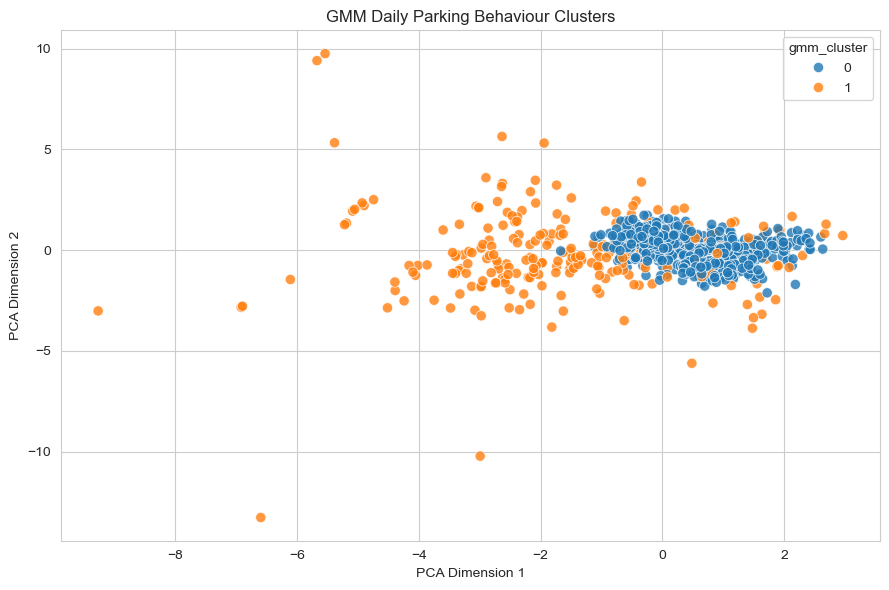

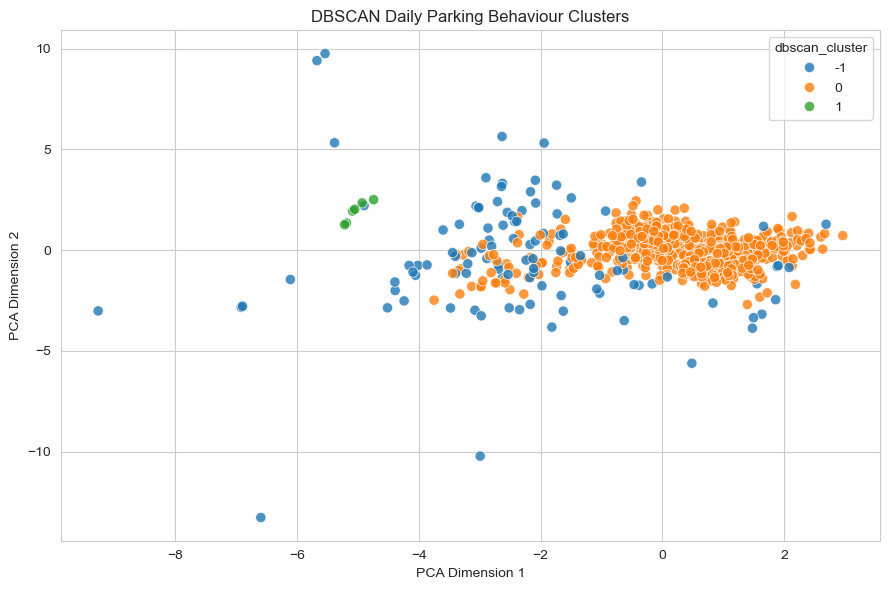

In [25]:
def plot_cluster_visualization(data, label_column, title, filename):
    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=data,
        x="PCA1",
        y="PCA2",
        hue=label_column,
        palette="tab10",
        s=55,
        alpha=0.8
    )

    plt.title(title)
    plt.xlabel("PCA Dimension 1")
    plt.ylabel("PCA Dimension 2")
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_cluster_visualization(
    daily_df,
    "kmeans_cluster",
    "K-Means Daily Parking Behaviour Clusters",
    "kmeans_cluster_visualization.png"
)

plot_cluster_visualization(
    daily_df,
    "gmm_cluster",
    "GMM Daily Parking Behaviour Clusters",
    "gmm_cluster_visualization.png"
)

plot_cluster_visualization(
    daily_df,
    "dbscan_cluster",
    "DBSCAN Daily Parking Behaviour Clusters",
    "dbscan_cluster_visualization.png"
)

## Interpret K-Means Behaviour Profiles  

In [26]:
kmeans_cluster_sizes = (
    daily_df["kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename("observations")
    .to_frame()
)

kmeans_cluster_sizes["percentage"] = (
    kmeans_cluster_sizes["observations"]
    / len(daily_df)
    * 100
).round(2)

kmeans_cluster_sizes

,observations,percentage
kmeans_cluster,,
0,150,14.810
1,863,85.190


In [27]:
kmeans_original_profiles = (
    daily_df.groupby("kmeans_cluster")
    [interpretation_features]
    .mean()
    .round(3)
)

kmeans_original_profiles

,total_transactions,median_duration,avg_duration,avg_amount,total_revenue,paid_ratio,early_morning_ratio,morning_ratio,afternoon_ratio,evening_ratio,is_weekend,extended_duration_flag
kmeans_cluster,,,,,,,,,,,,
0,11.627,722.401,"1,039.296",3.489,50.373,0.477,0.081,0.270,0.440,0.209,0.780,0.113
1,99.300,479.762,535.659,6.893,652.278,0.666,0.156,0.521,0.219,0.104,0.161,0.003


In [28]:
kmeans_relative_profiles = (
    daily_df.groupby("kmeans_cluster")
    [relative_features]
    .mean()
    .round(3)
)

kmeans_relative_profiles

,log_total_transactions_relative,log_median_duration_relative,paid_ratio_relative,early_morning_ratio_relative,morning_ratio_relative,afternoon_ratio_relative
kmeans_cluster,,,,,,
0,-1.756,-0.758,-1.049,0.529,-1.347,1.058
1,0.305,0.132,0.182,-0.092,0.234,-0.184


In [29]:
kmeans_site_distribution = pd.crosstab(
    daily_df["kmeans_cluster"],
    daily_df["site"],
    normalize="index"
).round(3)

kmeans_site_distribution

site,Site A,Site B,Site C
kmeans_cluster,,,
0,0.633,0.247,0.120
1,0.312,0.305,0.384


## Interpret GMM Profiles

In [30]:
gmm_cluster_sizes = (
    daily_df["gmm_cluster"]
    .value_counts()
    .sort_index()
    .rename("observations")
    .to_frame()
)

gmm_cluster_sizes["percentage"] = (
    gmm_cluster_sizes["observations"]
    / len(daily_df)
    * 100
).round(2)

gmm_original_profiles = (
    daily_df.groupby("gmm_cluster")
    [interpretation_features]
    .mean()
    .round(3)
)

gmm_site_distribution = pd.crosstab(
    daily_df["gmm_cluster"],
    daily_df["site"],
    normalize="index"
).round(3)

display(gmm_cluster_sizes)
display(gmm_original_profiles)
display(gmm_site_distribution)

,observations,percentage
gmm_cluster,,
0,762,75.220
1,251,24.780


,total_transactions,median_duration,avg_duration,avg_amount,total_revenue,paid_ratio,early_morning_ratio,morning_ratio,afternoon_ratio,evening_ratio,is_weekend,extended_duration_flag
gmm_cluster,,,,,,,,,,,,
0,107.136,486.613,530.191,6.925,693.165,0.657,0.163,0.517,0.221,0.099,0.109,0.000
1,23.116,603.968,853.238,4.763,168.446,0.578,0.089,0.383,0.346,0.182,0.689,0.080


site,Site A,Site B,Site C
gmm_cluster,,,
0,0.282,0.320,0.398
1,0.594,0.223,0.183


## Interpret DBSCAN Noise Observations

In [31]:
dbscan_noise_days = (
    daily_df[daily_df["dbscan_noise_flag"] == 1]
    [[
        "site",
        "entry_date",
        "total_transactions",
        "median_duration",
        "avg_amount",
        "total_revenue",
        "paid_ratio",
        "early_morning_ratio",
        "morning_ratio",
        "afternoon_ratio",
        "evening_ratio",
        "is_weekend",
        "extended_duration_flag"
    ]]
    .sort_values(
        by="median_duration",
        ascending=False
    )
)

print("Number of DBSCAN noise observations:", len(dbscan_noise_days))
dbscan_noise_days.head(20)

Number of DBSCAN noise observations: 110


,site,entry_date,total_transactions,median_duration,avg_amount,total_revenue,paid_ratio,early_morning_ratio,morning_ratio,afternoon_ratio,evening_ratio,is_weekend,extended_duration_flag
384,Site B,2025-01-25,2,"6,460.592",0.000,0.000,0.000,0.000,0.500,0.500,0.000,1,1
601,Site B,2025-10-18,1,"5,937.000",0.000,0.000,0.000,0.000,1.000,0.000,0.000,1,1
767,Site C,2025-04-14,4,"5,043.800",45.000,180.000,1.000,1.000,0.000,0.000,0.000,0,1
423,Site B,2025-03-16,1,"4,814.217",0.000,0.000,0.000,1.000,0.000,0.000,0.000,1,1
636,Site B,2025-11-29,3,"4,776.450",0.000,0.000,0.000,0.000,0.333,0.333,0.333,1,1
589,Site B,2025-10-04,4,"3,397.125",8.750,35.000,0.500,0.000,1.000,0.000,0.000,1,1
366,Site B,2025-01-04,3,"3,041.100",0.000,0.000,0.000,0.000,0.667,0.333,0.000,1,1
649,Site B,2025-12-14,1,"2,957.633",0.000,0.000,0.000,1.000,0.000,0.000,0.000,1,1
477,Site B,2025-05-24,1,"2,928.983",0.000,0.000,0.000,0.000,1.000,0.000,0.000,1,1
512,Site B,2025-07-05,2,"2,717.542",0.000,0.000,0.000,0.500,0.000,0.500,0.000,1,1


In [32]:
noise_extended_comparison = pd.crosstab(
    daily_df["dbscan_noise_flag"],
    daily_df["extended_duration_flag"],
    margins=True
)

noise_extended_comparison

extended_duration_flag,0,1,All
dbscan_noise_flag,,,
0,897,6,903
1,96,14,110
All,993,20,1013


In [33]:
dbscan_noise_days.to_csv(
    TABLE_DIR / "dbscan_noise_site_days.csv",
    index=False
)

## Export Final Clustering Dataset and Interpretation Tables

In [34]:
daily_df.to_csv(
    TABLE_DIR / "daily_parking_behaviour_with_cluster_labels.csv",
    index=False
)

kmeans_cluster_sizes.to_csv(
    TABLE_DIR / "kmeans_cluster_sizes.csv"
)

kmeans_original_profiles.to_csv(
    TABLE_DIR / "kmeans_original_profiles.csv"
)

kmeans_relative_profiles.to_csv(
    TABLE_DIR / "kmeans_relative_profiles.csv"
)

kmeans_site_distribution.to_csv(
    TABLE_DIR / "kmeans_site_distribution.csv"
)

gmm_cluster_sizes.to_csv(
    TABLE_DIR / "gmm_cluster_sizes.csv"
)

gmm_original_profiles.to_csv(
    TABLE_DIR / "gmm_original_profiles.csv"
)

gmm_site_distribution.to_csv(
    TABLE_DIR / "gmm_site_distribution.csv"
)

print("All clustering outputs have been saved successfully.")

All clustering outputs have been saved successfully.


In [36]:
DASHBOARD_DIR = PROJECT_ROOT / "outputs" / "dashboard"
DASHBOARD_DIR.mkdir(parents=True, exist_ok=True)

export_cols = [
    "site", "entry_date",
    "total_transactions", "median_duration", "avg_duration",
    "avg_amount", "total_revenue", "paid_ratio",
    "early_morning_ratio", "morning_ratio", "afternoon_ratio", "evening_ratio",
    "is_weekend",
    "extended_duration_flag",
    "kmeans_cluster", "dbscan_cluster", "dbscan_noise_flag",
    "PCA1", "PCA2",
]

missing = [c for c in export_cols if c not in daily_df.columns]
if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        "Run the full notebook top-to-bottom before exporting."
    )

daily_df[export_cols].to_csv(DASHBOARD_DIR / "site_day_clusters.csv", index=False)

print("Saved:", DASHBOARD_DIR / "site_day_clusters.csv")
print("Rows:", len(daily_df))
print("Cluster distribution:")
print(daily_df["kmeans_cluster"].value_counts().sort_index())

Saved: C:\Users\irfan\OneDrive\Documents\Education\Degree\Third Year\Sem 2\Investigation (fyp)\fyp part 1\parking_fyp\outputs\dashboard\site_day_clusters.csv
Rows: 1013
Cluster distribution:
kmeans_cluster
0    150
1    863
Name: count, dtype: int64
